In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
#
# Carga de datos
#
def load_data():
    df = pd.read_csv("files/input/shipping-data.csv")
    return df

#load_data().head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [29]:
# Visual for Shipping per Warehouse

def create_visual_for_shipping_per_warehouse(df):
    df = df.copy()
    plt.figure()
    counts = df.Warehouse_block.value_counts()
    #return counts
    counts.plot.bar(
        title="Shipping per Warehouse",
        xlabel="Warehouse block",
        ylabel="Record Count",
        color="tab:blue",
        fontsize=8
    )
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.savefig("shipping_per_warehouse.png")

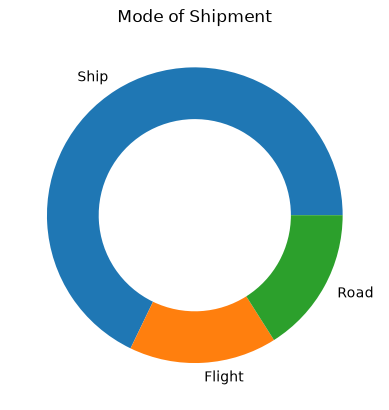

In [30]:
# Visual for Mode of Shipment

def create_visual_for_shipment(df):
    df = df.copy()
    plt.figure()
    counts = df.Mode_of_Shipment.value_counts()
    counts.plot.pie(
        title="Mode of Shipment",
        wedgeprops=dict(width=0.35),
        ylabel="",
        colors=["tab:blue", "tab:orange", "tab:green"],
    )
    plt.savefig("mode_of_shipment.png")


df = load_data()
create_visual_for_shipment(df)

In [24]:
# Visual for Average Customer Rating

def create_visual_for_average_customer_rating(df):
    df = df.copy()
    plt.figure()
    df = (
        df[["Mode_of_Shipment", "Customer_rating"]]
        .groupby("Mode_of_Shipment")
        .describe()
    )
    df.columns = df.columns.droplevel()
    df = df[["mean","min","max"]]
    plt.barh(
        y=df.index.values,
        width=df["max"].values -1,
        left=df["min"].values,
        height=0.9,
        color="lightgray",
        alpha=0.8,
    )
    colors = [
        "tab:green" if value >= 3.0 else "tab:orange" for value in df["mean"].values
    ]
    plt.barh(
        y=df.index.values,
        width=df["mean"].values -1,
        left=df["min"].values,
        color=colors,
        height=0.5,
        alpha=1.0,
    )
    plt.gca().spines["left"].set_color("gray")
    plt.gca().spines["bottom"].set_color("gray")
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.savefig("average_customer_rating.png")


In [26]:
# Visual for Weight Distribution

def create_visual_for_weight_distribution(df):
    df = df.copy()
    plt.figure()
    df.Weight_in_gms.plot.hist(
        title="Shipped Weight Distribution",
        color="tab:orange",
        edgecolor="white",
    )
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.savefig("weight_distribution.png")


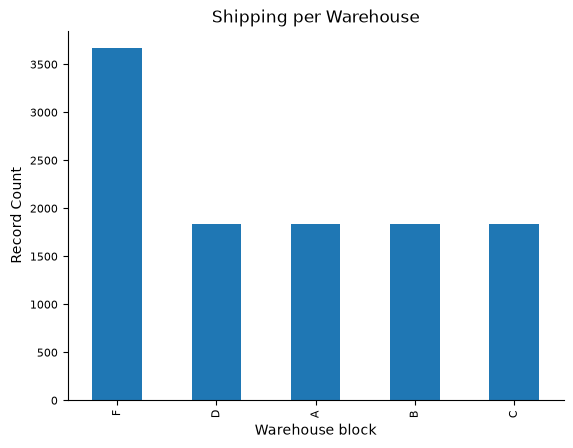

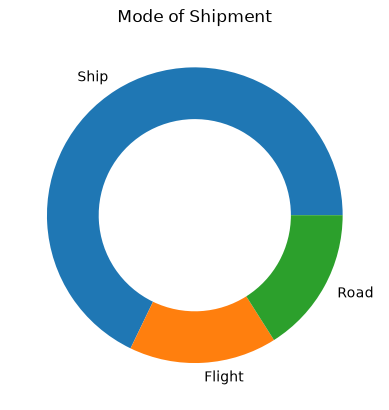

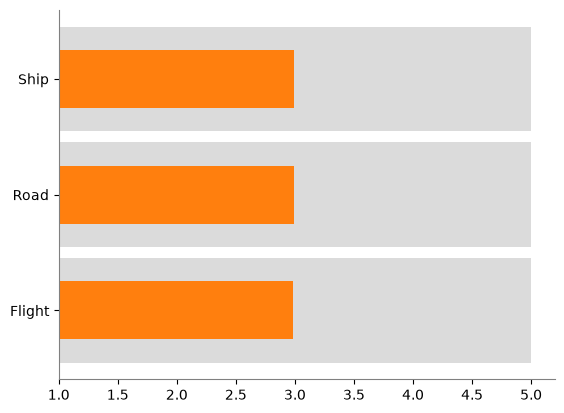

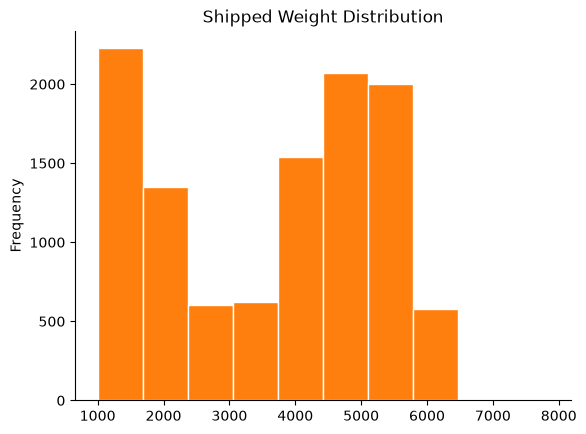

In [31]:
df = load_data()
create_visual_for_shipping_per_warehouse(df)
create_visual_for_shipment(df)
create_visual_for_average_customer_rating(df)
create_visual_for_weight_distribution(df)

In [32]:
%%writefile index.html

<!DOCTYPE html>
<html>
   <body>
         <h1>Shipping Dashboard</h1>
         <div style="width:45%;float:left">
            <img src="shipping_per_warehouse.png" alt="Fig 1">
            <img src="mode_of_shipment.png" alt="Fig 2">
        </div>
        <div style="width:45%;float:left">
            <img src="average_customer_rating.png" alt="Fig 3">
            <img src="weitght distribution.png" alt="Fig 4">
        </div>
   </body>
</html>

Writing index.html
